In [340]:
import os
import keras.losses
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from copy import deepcopy

In [341]:
# --- データ定義 ---
data_dir = "C:/Users/takat/Desktop/sotuken/dat_to_images_64"

#辞書にしとけ
# ラベルがついているPBMファイル
labeled_pbm = [
    # Mild
    'AF483470.1.pbm', 'EF192393.1.pbm', 'EF192394.1.pbm', 'EF580923.1.pbm', 'EU879915.1.pbm',
    'EU879916.1.pbm', 'JQ806338.1.pbm', 'KF418767.1.pbm', 'KR611355.1.pbm', 'KT987925.1.pbm',
    'LC388852.1.pbm', 'LC388854.1.pbm', 'M25199.1.pbm', 'MG450357.1.pbm', 'Y09575.1.pbm',
    # Moderate
    'AF454395.1.pbm', 'KF683200.1.pbm', 'KJ857496.1.pbm', 'KR611360.1.pbm', 'M88678.1.pbm',
    'X17268.1.pbm', 'GQ853461.1.pbm', 'EU879913.1.pbm',
    # Severe
    'AJ634596.1.pbm', 'AY518939.1.pbm', 'AY532801.1.pbm', 'DD220185.1.pbm', 'FR851463.1.pbm',
    'JX280944.1.pbm', 'U23060.1.pbm', 'X58388.1.pbm', 'X76846.1.pbm', 'X97387.1.pbm',
    'Y09383.1.pbm', 'LC523672.1.pbm', 'LC523675.1.pbm', 'LC523676.1.pbm'
]

# 重症度ラベル（0: mild, 1: moderate, 2: severe）
labels = [
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,   # mild (15)
    1, 1, 1, 1, 1, 1, 1, 1,                       # moderate (8)
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2       # severe (14)
]
label_dict = dict(zip(labeled_pbm, labels))

filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pbm")]
labels_list = [label_dict.get(os.path.basename(fp), -1) for fp in filepaths]

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 1
num_classes = 3
label_map = {0:"mild", 1:"moderate", 2:"severe"}

In [342]:
def load_and_preprocess_list(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p).convert('L').resize((64, 64)), dtype=np.float32)
        img = np.expand_dims(img, axis=-1)
        X.append(img)
    return np.array(X)

In [343]:
def load_and_preprocess_list_gabege(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        img /= 1.0
        X.append(img)
    #print(len(X),len(X[0]),len(X[0][0]),len(X[0][0][0]))
    return np.array(X)

In [344]:
def make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.1))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


In [345]:
def jackknife_on_files(labeled_file_list, labeled_label_list, epochs, verbose=1):
    n = len(labeled_file_list)
    preds_all = []
    true_all = []
    accs = []

    X = load_and_preprocess_list(labeled_file_list)
    y = np.array(labeled_label_list, dtype=np.int32)

    for i in range(n):
        print(f"Fold {i+1}/{n}")
        mask = np.arange(n) != i
        #print(mask)
        x_train = X[mask]
        y_train = y[mask]
        x_test = X[[i]]
        y_test = y[[i]]

        #print(x_test)

       # print(len(x_train))

        model = make_model()
        model.compile(optimizer=optimizers.Adam(1e-5),
                      loss=losses.SparseCategoricalCrossentropy(),
                      metrics=['accuracy'])
        model.fit(x_train, y_train, epochs=100, verbose=verbose, validation_data=(x_test, y_test))

        pred = np.argmax(model.predict(x_test), axis=1)[0]

        preds_all.append(pred)
        true_all.append(y_test[0])
        accs.append(int(pred == y_test[0]))

    return np.array(preds_all), np.array(true_all), np.array(accs)


In [346]:
labeled_fullpaths = [os.path.join(data_dir, name) for name in labeled_pbm]
preds, trues, accs = jackknife_on_files(labeled_fullpaths, labels, epochs=20)
print(f"Jackknife average accuracy: {np.mean(accs):.4f}")
#検証用のラベルCSV
#val_accの100個目のモノで平均とる
#辞書紐づけ

Fold 1/37


C:\Users\takat\Desktop\sotuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 387ms/step - accuracy: 0.2778 - loss: 10.6867 - val_accuracy: 1.0000 - val_loss: 4.0531e-06
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4167 - loss: 6.6131 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4722 - loss: 6.1989 - val_accuracy: 1.0000 - val_loss: 4.7684e-07
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4444 - loss: 5.2011 - val_accuracy: 1.0000 - val_loss: 9.5367e-07
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4722 - loss: 6.8236 - val_accuracy: 1.0000 - val_loss: 1.3113e-06
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5000 - loss: 5.0952 - val_accuracy: 1.0000 - val_loss: 3.6955e-06
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5833 - loss: 6.2449 - val_accuracy: 1.0000 - val_loss: 4.6492e-06
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4444 - loss: 6.5975 - v

Epoch 1/10


C:\Users\takat\Desktop\sotuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5172 - loss: 8.1874 - val_accuracy: 0.8750 - val_loss: 0.3934
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2759 - loss: 10.1813 - val_accuracy: 0.7500 - val_loss: 2.9363
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3793 - loss: 5.8926 - val_accuracy: 0.2500 - val_loss: 7.9760
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5862 - loss: 4.2224 - val_accuracy: 0.0000e+00 - val_loss: 13.9147
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5517 - loss: 5.1609 - val_accuracy: 0.0000e+00 - val_loss: 15.7258
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5862 - loss: 5.5752 - val_accuracy: 0.0000e+00 - val_loss: 13.4583
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5172 - loss: 3.4578 - val_accuracy: 0.0000e+00 - val_loss: 9.1716
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5172 - loss: 4.5034 - val_accuracy: 0.2500 - val

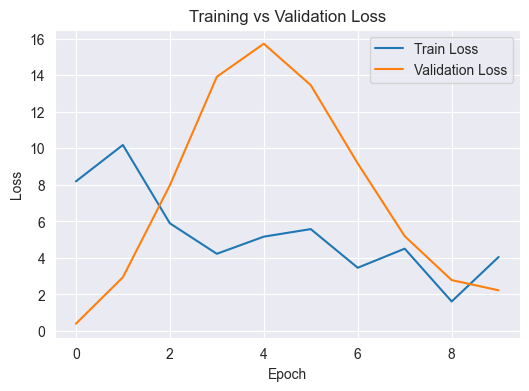

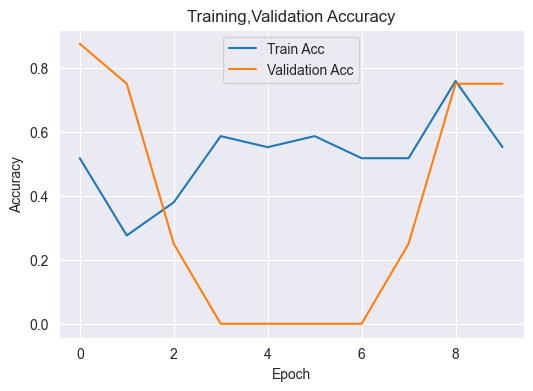

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

In [347]:
df_jk = pd.DataFrame({
    "Filename": [os.path.basename(p) for p in labeled_fullpaths],
    "True_Label": [label_map[int(v)] for v in trues],
    "Predicted_Label": [label_map[int(v)] for v in preds]
})
df_jk.to_csv("jackknife_results.csv", index=False, encoding="utf-8-sig")

X_train_all = load_and_preprocess_list(labeled_fullpaths)
y_train_all = np.array(labels, dtype=np.int32)

#37分割文やつ使って予測

final_model = make_model()
final_model.compile(optimizer=optimizers.Adam(1e-4),
                    loss=losses.SparseCategoricalCrossentropy(),
                    metrics=['accuracy'])


history = final_model.fit(
    X_train_all,
    y_train_all,
    epochs=10,
    verbose=1,
    validation_split=0.2,

)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Validation Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training,Validation Accuracy")
plt.show()


all_results = []
for p, lb in zip(filepaths, labels_list):
    img = load_and_preprocess_list([p])
    pred = np.argmax(final_model.predict(img), axis=1)[0]
    all_results.append({
        "DataType": "Labeled" if lb != -1 else "Unlabeled",
        "Filename": os.path.basename(p),
        "True_Severity": label_map[lb] if lb != -1 else None,
        "Predicted_Severity": label_map[int(pred)]
    })

df_all = pd.DataFrame(all_results)
df_all.to_csv("all_data_predictions_tf.csv", index=False, encoding="utf-8-sig")
print("finish")